In [ ]:
print('Cosmos')

Cosmos


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
R_earth = 6371032
mu = 3.986004418e14
h = 550000
inclination_deg = 53
a = R_earth + h
print (a)

6921032


In [ ]:
T_period = 2 * np.pi * np.sqrt(a**3/mu)
n = 2 * np.pi / T_period
print ('T_period =', T_period ,('секунд'))
print ('n =', n ,('Радиан в секунду'))

T_period = 5730.166830183936 секунд
n = 0.0010965100133005898 Радиан в секунду


In [ ]:
def position_in_orbite_plane (t):
    nu0 = 0
    nu = nu0 + n * t
    x_orbit = a * np.cos(nu)
    y_orbit = a * np.sin(nu)
    z_orbit = 0.0
    return (x_orbit, y_orbit, z_orbit)
print (position_in_orbite_plane(0))
print (position_in_orbite_plane(900))

(np.float64(6921032.0), np.float64(0.0), 0.0)
(np.float64(3815655.587901373), np.float64(5774206.12548089), 0.0)


In [ ]:
def orbit_to_equatorial (x_orbit, y_orbit, z_orbit, inc_deg, raan_deg, arg_per_deg):
    inc_rad = np.radians(inc_deg)
    raan_rad = np.radians(raan_deg)
    arg_per_rad = np.radians(arg_per_deg)
    x_1 = x_orbit * np.cos(arg_per_rad) - y_orbit * np.sin(arg_per_rad)
    y_1 = x_orbit * np.sin(arg_per_rad) + y_orbit * np.cos(arg_per_rad)
    z_1 = z_orbit

    x_2 = x_1
    y_2 = y_1 * np.cos(inc_rad) - z_1 * np.sin(inc_rad)
    z_2 = y_1 * np.sin(inc_rad) + z_1 * np.cos(inc_rad)

    x_eq = x_2 * np.cos(raan_rad) - y_2 * np.sin(raan_rad)
    y_eq = x_2 * np.sin(raan_rad) + y_2 * np.cos(raan_rad)
    z_eq = z_2

    return (x_eq, y_eq, z_eq)
    
print (orbit_to_equatorial (10,14,54,53,45,90))

(np.float64(16.339941806424974), np.float64(-36.13893167964831), np.float64(40.48436635068354))


In [ ]:

x_orbit, y_orbit, z_orbit = position_in_orbite_plane(t)

inc_deg = 53
raan_deg = 47
arg_per_deg = 0

X,Y,Z = orbit_to_equatorial(x_orbit, y_orbit, z_orbit, inc_deg, raan_deg, arg_per_deg)

print("\nГлобальные координаты (от центра Земли):")
print(f"  X = {X:.2f} м")
print(f"  Y = {Y:.2f} м")
print(f"  Z = {Z:.2f} м")

r = (X**2 + Y**2 + Z**2)**0.5

print(f"\nРасстояние от центра Земли: {r:.2f} м")
# Сравните с большой полуосью a (она у вас определена ранее)
print(f"Большая полуось a = {a:.2f} м")
print(f"Разница: {r - a:.2f} м (должна быть почти 0)")


Глобальные координаты (от центра Земли):
  X = 4720132.47 м
  Y = 5061722.37 м
  Z = -0.00 м

Расстояние от центра Земли: 6921032.00 м
Большая полуось a = 6921032.00 м
Разница: -0.00 м (должна быть почти 0)


Количество точек: 200
5730.166830183936
Первая точка: 4720132.4739400735 5061722.37222473 0.0
Последняя точка: 4720132.473940074 5061722.3722247295 -1.3538181155350338e-09
Минимумы X, Y, Z: -5617409.495850466 -5804069.644578197 -5527209.7262596
Максимумы X, Y, Z: 5617685.305410639 5804222.815222743 5527209.7262596


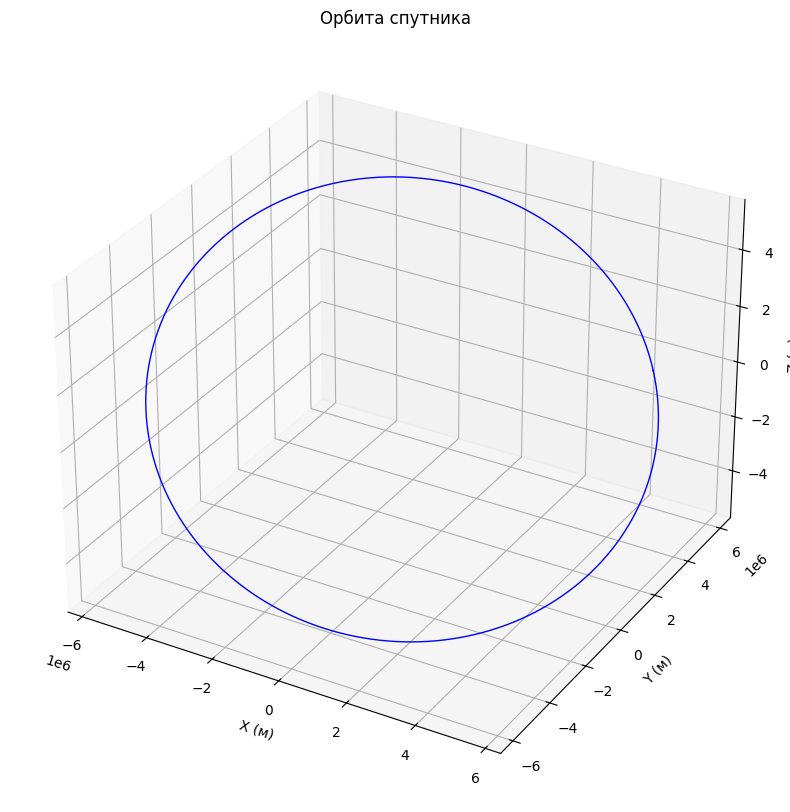

In [ ]:
t_span = np.linspace(0,T_period,200)

X_orbit = []
Y_orbit = []
Z_orbit = []

for t in t_span:
    xo, yo, zo = position_in_orbite_plane(t)
    X, Y, Z = orbit_to_equatorial(xo, yo, zo, inc_deg, raan_deg, arg_per_deg)
    X_orbit.append(X)
    Y_orbit.append(Y)
    Z_orbit.append(Z)
    
print("Количество точек:", len(X_orbit))
print(T_period)
print("Первая точка:", X_orbit[0], Y_orbit[0], Z_orbit[0])
print("Последняя точка:", X_orbit[-1], Y_orbit[-1], Z_orbit[-1])
print("Минимумы X, Y, Z:", min(X_orbit), min(Y_orbit), min(Z_orbit))
print("Максимумы X, Y, Z:", max(X_orbit), max(Y_orbit), max(Z_orbit))

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot(X_orbit, Y_orbit, Z_orbit, 'b-', linewidth=1)
ax.set_xlabel('X (м)'); ax.set_ylabel('Y (м)'); ax.set_zlabel('Z (м)')
ax.set_title('Орбита спутника')
plt.show()

In [ ]:
lon_sat = np.degrees(np.arctan2(Y, X))
lat = np.degrees(np.arcsin(Z / np.sqrt(X**2+Y**2+Z**2)))

omega_earth = 7.292115e-5  # рад/с
lon_ground = lon_sat - np.degrees(omega_earth * t)
lon_ground = (lon_ground + 180) % 360 - 180

print(f"Подспутниковая точка: широта {lat:.2f}°, долгота {lon_ground:.2f}°")

Подспутниковая точка: широта -0.00°, долгота 23.06°
